# Import Required Packages

In [96]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Data Download from WRDS via SQL

In [97]:
## set download location for files
data_location = r"C:\Github Code\quant-factor-engine\data"

## connect to wrds to download data via SQL query
db = wrds.Connection()

############### Downloading fundamentals table from Compustat ###############
## join compustat fundamentals table with the Linktable in the SQL query to link the 'PERMNO' (CRSP ID) for later linking with CRSP price data

fund_query = """
SELECT 
    a.gvkey, a.datadate, a.tic, a.conm,
    b.lpermno as permno, b.linktype, b.linkenddt,
    
    -- Value Fundamentals
    a.seq, a.ceq, a.pstk, a.pstkrv, a.pstkl, a.txditc,
    
    -- Profitability Fundamentals
    a.revt, a.cogs, a.xsga, a.xint, a.ib, a.dp,
    
    -- Growth and Investment Fundamentals
    a.at, a.capx, a.ppent,
    
    -- Leverage Fundamentals
    a.act, a.lct, a.che, a.dltt, a.dlc, a.invt, a.rect
FROM 
    comp.funda a
LEFT JOIN 
    crsp.ccmxpf_linktable b 
    ON a.gvkey = b.gvkey
    AND b.linktype IN ('LU', 'LC')
    AND b.linkprim IN ('P', 'C') 
    
WHERE 
    a.datadate >= '01/01/2010'
    AND a.indfmt = 'INDL'
    AND a.datafmt = 'STD'
    AND a.popsrc = 'D'
    AND a.consol = 'C'
"""
print("Fetching Fundamentals Data from Compustat...")
df_fund = db.raw_sql(fund_query)
## save data as parquet for later retrieval during data processing phase
df_fund.to_parquet(data_location + r'\compustat_fundamentals.parquet', engine='fastparquet')

############### Downloading monthly stock data from CRSP ###############
# This data is used for Momentum, Market Cap, Beta, and Monthly Returns
# We filter by share code 10 or 11 to get only "Common Stocks" (no ETFs/ADRs in factor construction usually)

### Guide to Share codes
## Share Codes are a 2-digit integer code describing the type of shares traded.
## 1. First Digit - Describes the type of security traded
# 1	|Ordinary Common Share
# 2	|Certificates
# 3	|ADRs (American Depository Receipts)
# 4	|SBIs (Shares of Beneficial Interest)
# 7	|Units (Depository Units, etc.)

## 2. Second Digit - Describes the Status or location of the company (e.g. Domestic, Foreign, Closed-end fund)
# Digit,Meaning
# 0 |No special status (Standard)
# 1 |No special status (Standard)
# 2 |Foreign Incorporated
# 3 |Americus Trust Components
# 4 |Closed-End Fund
# 5 |Closed-End Fund (Foreign)
# 8 |REIT (Real Estate Investment Trust)

msf_query = """
SELECT 
    a.permno, a.date, 
    a.prc, a.ret, a.shrout, a.vol, a.cfacpr, a.cfacshr
FROM 
    crsp.msf a
LEFT JOIN 
    crsp.msenames b 
    ON a.permno = b.permno
    AND b.namedt <= a.date 
    AND a.date <= b.nameendt
WHERE 
    a.date >= '01/01/2010'
    AND b.shrcd IN (10, 11) -- Only US Common Stocks
"""
print("Fetching Monthly Prices...")
df_msf = db.raw_sql(msf_query)
df_msf.to_parquet(data_location + r'\crsp_US_monthly.parquet', engine='fastparquet')

############### Downloading daily stock data from CRSP ###############
# This data is used for GARCH, Volatility, VaR
# We only grab 'ret' (returns) to save space.

dsf_query = """
SELECT 
    a.permno, a.date, a.ret
FROM 
    crsp.dsf a
INNER JOIN 
    crsp.msenames b 
    ON a.permno = b.permno
    AND b.namedt <= a.date 
    AND a.date <= b.nameendt
WHERE 
    a.date >= '01/01/2010'
    AND b.shrcd IN (10, 11) -- Only US Common Stocks
"""
print("Fetching Daily Prices...")
df_dsf = db.raw_sql(dsf_query)
df_dsf.to_parquet(data_location + r'\crsp_US_daily.parquet', engine='fastparquet')

print("All downloads complete.")
db.close()

Enter your WRDS username [Admin]: xenith
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  yes
Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\Admin\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Fetching Fundamentals Data from Compustat...
Fetching Monthly Prices...
Fetching Daily Prices...
All downloads complete.


# Checking and Cleaning Data
## Checking Number of Unique Companies

Loading Compustat Fundamental data...
Loading CRSP US monthly raw data...
Loading CRSP US daily raw data...


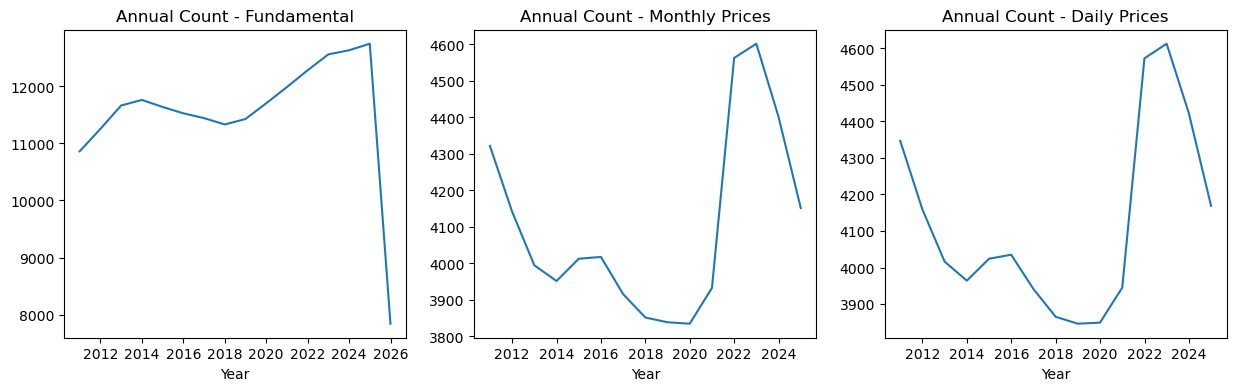

In [98]:
############## Check Fundamental Data from Compustat ##############
print("Loading Compustat Fundamental data...")
df_fund = pd.read_parquet(data_location + r'\compustat_fundamentals.parquet', engine='fastparquet')

## Plot number of unique companies in Fundamental Dataset
## Resampling to yearly is necessary here because companies release fundamental data at FY-end, causing a spike in the monthly numbers
# Converting datadate to datetime
df_fund['datadate'] = pd.to_datetime(df_fund['datadate'])
# Resample to 'YE' (Year End) and count unique firms
annual_coverage_fundamental = df_fund.set_index('datadate').resample('YE')['gvkey'].nunique()


############## Check Monthly Price Data from CRSP ##############
print("Loading CRSP US monthly raw data...")
df_crsp_monthly = pd.read_parquet(data_location + r'\crsp_US_monthly.parquet', engine='fastparquet')

# Count unique firms per month
df_crsp_monthly['date'] = pd.to_datetime(df_crsp_monthly['date'])
annual_coverage_monthly_prices = df_crsp_monthly.set_index('date').resample("YE")['permno'].nunique()
### Data reflects spikes in post-covid IPO's and SPACs


############## Check Daily Price Data from CRSP ##############
print("Loading CRSP US daily raw data...")
df_crsp_daily = pd.read_parquet(data_location + r'\crsp_US_daily.parquet', engine='fastparquet')

# Count unique firms per month
df_crsp_daily['date'] = pd.to_datetime(df_crsp_daily['date'])
annual_coverage_daily_prices = df_crsp_daily.set_index('date').resample("YE")['permno'].nunique()


############## PLot graph of number of Unique Companies over the period ##############
fig, axis = plt.subplots(1, 3, figsize=(15, 4))
axis[0].plot(annual_coverage_fundamental)
axis[0].set_title('Annual Count - Fundamental')
axis[0].set_xlabel('Year')

axis[1].plot(annual_coverage_monthly_prices)
axis[1].set_title('Annual Count - Monthly Prices')
axis[1].set_xlabel('Year')

axis[2].plot(annual_coverage_daily_prices)
axis[2].set_title('Annual Count - Daily Prices')
axis[2].set_xlabel('Year')

plt.show()

### Checking that Units for Tables are Correct

In [99]:
############## Check Fundamental Data from Compustat ##############
# Verify all columns are in $ Millions (roughly order of magnitude 100-5000)
# Key columns to check magnitude
print("1. Checking Fundamentals (Units)...")
fund_cols = ['seq', 'revt', 'at', 'che', 'lct'] # Equity, Revenue, Assets, Cash, Current Liabilities

print("   [Median Values in $ Millions]")
print(df_fund[fund_cols].median().to_string())

# Assets must be > Equity, and usually > Revenue
median_at = df_fund['at'].median()
median_seq = df_fund['seq'].median()

if median_at > median_seq:
    print(f"   [PASS] Assets ({median_at:.0f}) > Equity ({median_seq:.0f}). Structure is logical.")
else:
    print(f"   [FAIL] Assets ({median_at:.0f}) < Equity ({median_seq:.0f}). Data corruption likely.")
print("-" * 50)

############## Check Monthly Price Data from CRSP ##############
# Verify Price is $, Shares are 000s, Market Cap is $000s
print("2. Checking Monthly Prices (Units)...")

# Fix negative prices (Bid/Ask averages) just for this check
df_crsp_monthly['prc_abs'] = df_crsp_monthly['prc'].abs()

# Calculate Implied Market Cap (in Millions) to compare with Fundamentals
# Formula: (Price * Shares_in_000s) / 1000 = $ Millions
df_crsp_monthly['mkt_cap_mil'] = (df_crsp_monthly['prc_abs'] * df_crsp_monthly['shrout']) / 1000

print("   [Key Medians]")
print(f"   Price ($):             {df_monthly['prc_abs'].median():.2f}")
print(f"   Shares (000s):         {df_monthly['shrout'].median():.0f}")
print(f"   Mkt Cap ($ Millions):  {df_monthly['mkt_cap_mil'].median():.2f}")

# Cross-Reference Logic: Market Cap (Monthly) should be roughly similar to Equity (Fundamentals)
# If Mkt Cap is 0.5 and Equity is 500, units are wrong.
ratio = df_monthly['mkt_cap_mil'].median() / median_seq
print(f"   [CHECK] Market Cap / Book Equity Ratio: {ratio:.2f} (Should be roughly 1.0 - 4.0)")
print("-" * 50)


############## Check Daily Price Data from CRSP ##############
# Verify Daily Price range matches Monthly Price range
# ==============================================================================
print("3. Checking Daily Prices (Consistency)...")
# Use a sample for speed (Daily is huge)
daily_sample = df_crsp_daily['ret'].dropna().sample(100000)

print("   [Daily Returns Stats]")
print(f"   Mean Daily Return: {daily_sample.mean():.4%}")
print(f"   Min Return:        {daily_sample.min():.2%}")
print(f"   Max Return:        {daily_sample.max():.2%}")

# Logic Check: Daily returns should be small (e.g., +/- 1-2%).
if abs(daily_sample.mean()) < 0.01:
    print("   [PASS] Daily returns are within expected magnitude (<1%).")
else:
    print("   [FAIL] Daily returns look too large. Are they percentage (5.0) instead of decimal (0.05)?")

print("\n=== CHECKS COMPLETE ===")

1. Checking Fundamentals (Units)...
   [Median Values in $ Millions]
seq     149.219
revt    173.925
at      475.322
che      42.291
lct      51.319
   [PASS] Assets (475) > Equity (149). Structure is logical.
--------------------------------------------------
2. Checking Monthly Prices (Units)...
   [Key Medians]
   Price ($):             21.12
   Shares (000s):         26897
   Mkt Cap ($ Millions):  348.15
   [CHECK] Market Cap / Book Equity Ratio: 2.33 (Should be roughly 1.0 - 4.0)
--------------------------------------------------
3. Checking Daily Prices (Consistency)...
   [Daily Returns Stats]
   Mean Daily Return: 0.0565%
   Min Return:        -70.68%
   Max Return:        255.17%
   [PASS] Daily returns are within expected magnitude (<1%).

=== CHECKS COMPLETE ===


# Add calculations for each table (Fundamental and Monthly)

In [101]:
# ==========================================
# STEP 1: PREP FUNDAMENTALS
# ==========================================
print("Calculating fundamental factors...")

print(f"Fund rows before dedupe: {len(df_fund)}")
# 1. Deduplicate (Keep most recent update for a fiscal year)
df_fund = df_fund.sort_values(['gvkey', 'datadate'])
df_fund = df_fund.drop_duplicates(subset=['gvkey', 'datadate'], keep='last')
df_fund = df_fund.dropna(subset=['permno']) # Cannot link without PERMNO
print(f"Fund rows after dedupe: {len(df_fund)}")

# 2. Fill MINOR missing values only (Safe Fill)
# We do NOT fill 'seq' or 'revt'. If those are missing, we drop the row later.
df_fund['txditc'] = df_fund['txditc'].fillna(0)
df_fund['pstkrv'] = df_fund['pstkrv'].fillna(0) # Redemption Value
df_fund['pstkl']  = df_fund['pstkl'].fillna(0)  # Liquidating Value
df_fund['pstk']   = df_fund['pstk'].fillna(0)   # Carrying Value
df_fund['xsga']   = df_fund['xsga'].fillna(0)
df_fund['xint']   = df_fund['xint'].fillna(0)

# 3. Calculate Preferred Stock (The Fama-French Hierarchy)
# Use Redemption > Liquidating > Carrying
df_fund['ps'] = np.where(df_fund['pstkrv'] > 0, df_fund['pstkrv'],
                         np.where(df_fund['pstkl'] > 0, df_fund['pstkl'], 
                                  df_fund['pstk']))

# 4. Calculate Book Equity (BE)
# BE = Shareholders Equity + Deferred Taxes - Preferred Stock
df_fund['be'] = df_fund['seq'] + df_fund['txditc'] - df_fund['ps']
df_fund = df_fund[df_fund['be'] > 0] # Drop negative equity (distressed firms)

# 5. Calculate Operating Profitability (OP)
# OP = (Revenue - COGS - SG&A - Interest) / BE
df_fund['op_prof'] = (df_fund['revt'] - df_fund['cogs'] - df_fund['xsga'] - df_fund['xint']) / df_fund['be']

# 6. Calculate Asset Growth
df_fund = df_fund.sort_values(['gvkey', 'datadate'])
df_fund['asset_growth'] = df_fund.groupby('gvkey')['at'].pct_change()

# 7. Setup Dates (6 Month Lag)
df_fund['datadate'] = pd.to_datetime(df_fund['datadate'])
df_fund['public_date'] = df_fund['datadate'] + pd.DateOffset(months=6)

# Final Fundamental Cleanup
fund_cols = ['permno', 'public_date', 'be', 'op_prof', 'asset_growth']
df_fund = df_fund[fund_cols].dropna()

# ==========================================
# STEP 2: PREP PRICES (CRSP MONTHLY)
# ==========================================
print("Calculating price-based factors...")

df_crsp_monthly['date'] = pd.to_datetime(df_crsp_monthly['date'])
df_crsp_monthly = df_crsp_monthly.sort_values(['permno', 'date'])

# A. Market Cap (Price * Shares)
# Units: Price ($) * Shares (000s) = Market Cap ($000s)
df_crsp_monthly['mkt_cap'] = df_crsp_monthly['prc'].abs() * df_crsp_monthly['shrout']

# B. Momentum
df_crsp_monthly['log_ret'] = np.log(1 + df_crsp_monthly['ret'])
df_crsp_monthly['momentum'] = df_crsp_monthly.groupby('permno')['log_ret'].transform(
    lambda x: x.rolling(window=11).sum().shift(2)
)

# ==========================================
# STEP 3: MERGE & DIAGNOSTICS
# ==========================================
print("Merging datasets...")

df_crsp_monthly["permno"] = df_crsp_monthly["permno"].astype("float64")
df_fund["permno"] = df_fund["permno"].astype("float64")

df_crsp_monthly = df_crsp_monthly.sort_values('date')
df_fund = df_fund.sort_values('public_date')

# Capture Pre-Merge count for diagnostics
n_crsp_rows = len(df_crsp_monthly)

# Merge
df_combined = pd.merge_asof(
    df_crsp_monthly, 
    df_fund, 
    left_on='date', 
    right_on='public_date', 
    by='permno',
    direction='backward'
)

# ==========================================
# STEP 4: FINAL CLEANUP & SAVE
# ==========================================
# Calculate Book-to-Market
# BE is Millions. Mkt Cap is Thousands. 
# B/M = (BE * 1000) / Mkt Cap
df_combined['b_m'] = df_combined['be'] * 1000 / df_combined['mkt_cap']

# Filter Universe (Remove Penny Stocks & Tiny Caps)
# Mkt Cap > 100,000 means > $100 Million (since units are thousands)
df_final = df_combined[df_combined['mkt_cap'] > 100000].copy() 

# Drop rows where we don't have our primary signals
df_final = df_final.dropna(subset=['b_m', 'op_prof', 'momentum'])

# --- DIAGNOSTICS PRINT ---
n_final_rows = len(df_final)
match_efficiency = n_final_rows / n_crsp_rows

print("\n=== MERGE DIAGNOSTICS ===")
print(f"Original Price Rows:   {n_crsp_rows}")
print(f"Final Valid Rows:      {n_final_rows}")
print(f"Match Efficiency:      {match_efficiency:.1%}")
print("Efficiency ~50-60% is normal (drops small caps/ETFs/missing data).")

# Save
df_final.to_parquet(data_location + r'\factor_data.parquet', engine='fastparquet')
print("\nSaved to data/factor_data.parquet")

Calculating fundamental factors...
Fund rows before dedupe: 201038
Fund rows after dedupe: 102493
Calculating price-based factors...
Merging datasets...

=== MERGE DIAGNOSTICS ===
Original Price Rows:   697022
Final Valid Rows:      391176
Match Efficiency:      56.1%
Note: Efficiency ~60-70% is normal (drops small caps/ETFs/missing data).

Saved to data/factor_data.parquet


# Run Winsorization and Regression to check correlation

=== DATA SHAPE ===
Rows: 391176, Columns: 18
Unique Stocks: 5190
Date Range: 2011-06-30 00:00:00 to 2024-12-31 00:00:00

=== MISSING / INFINITE CHECK ===
permno          0
date            0
prc             0
ret             0
shrout          0
vol             0
cfacpr          0
cfacshr         0
prc_abs         0
mkt_cap_mil     0
mkt_cap         0
log_ret         0
momentum        0
public_date     0
be              0
op_prof         0
asset_growth    0
b_m             0
dtype: int64

=== DESCRIPTIVE STATS (AFTER WINSORIZATION) ===
                 b_m        op_prof   asset_growth       momentum
count  391176.000000  391176.000000  391176.000000  391176.000000
mean        0.563711       0.162741       0.159869       0.058785
std         0.509661       0.660853       0.422987       0.412316
min         0.011316      -3.040777      -0.387268      -1.290724
25%         0.211098       0.083136      -0.011677      -0.140585
50%         0.434846       0.189736       0.058538       0.08196

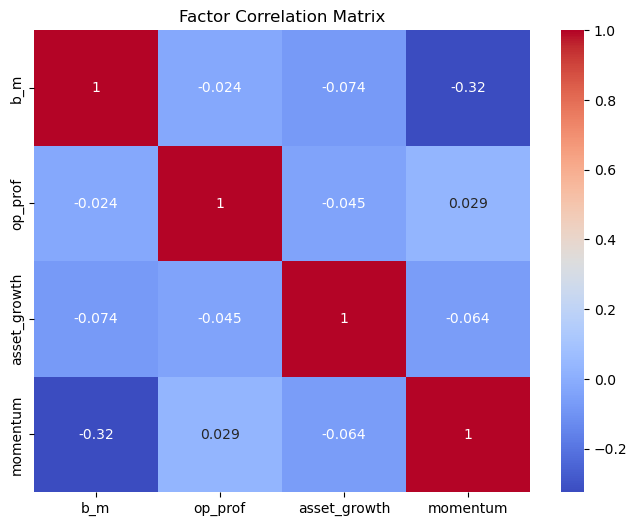

In [107]:
"""
DATA DICTIONARY (CRSP/Compustat Standard Codes)
------------------------------------------------
permno       : Permanent Company Number (Unique ID for a stock, unlike Ticker)
date         : Trading Date (Month End)
prc          : Closing Price (Take abs() to handle bid/ask averages)
ret          : Monthly Total Return (includes dividends)
shrout       : Shares Outstanding (in thousands)
vol          : Trading Volume
mkt_cap      : Market Capitalization (prc * shrout)
b_m          : Book-to-Market Ratio (Signal: Value)
op_prof      : Operating Profitability (Signal: Quality)
asset_growth : Asset Growth YoY (Signal: Investment)
momentum     : 12-1 Month Cumulative Return (Signal: Trend)
"""


print("=== DATA SHAPE ===")
print(f"Rows: {df_final.shape[0]}, Columns: {df_final.shape[1]}")
print(f"Unique Stocks: {df_final['permno'].nunique()}")
print(f"Date Range: {df_final['date'].min()} to {df_final['date'].max()}")

# 2. The "Infinity" & Null Check
# Factors like Book-to-Market can be infinite if Market Cap is near 0.
print("\n=== MISSING / INFINITE CHECK ===")
print(df_final.replace([np.inf, -np.inf], np.nan).isnull().sum())

# Drop missing/infinite values immediately
df_final = df_final.replace([np.inf, -np.inf], np.nan).dropna()

# 3. Winsorization (The "Quant" Secret)
# We clip the top/bottom 1% of factor values to remove outliers.
from scipy.stats.mstats import winsorize

factors = ['b_m', 'op_prof', 'asset_growth', 'momentum']

for f in factors:
    # Limits=[0.01, 0.01] means clip the bottom 1% and top 1%
    df_final[f] = winsorize(df_final[f], limits=[0.01, 0.01])

print("\n=== DESCRIPTIVE STATS (AFTER WINSORIZATION) ===")
# These means should look reasonable (e.g., B/M shouldn't be 5000)
print(df_final[factors].describe())

# 4. Correlation Matrix
# If factors are 0.9 correlated, you have multicollinearity (bad for regression).
plt.figure(figsize=(8, 6))
sns.heatmap(df_final[factors].corr(), annot=True, cmap='coolwarm')
plt.title("Factor Correlation Matrix")
plt.show()

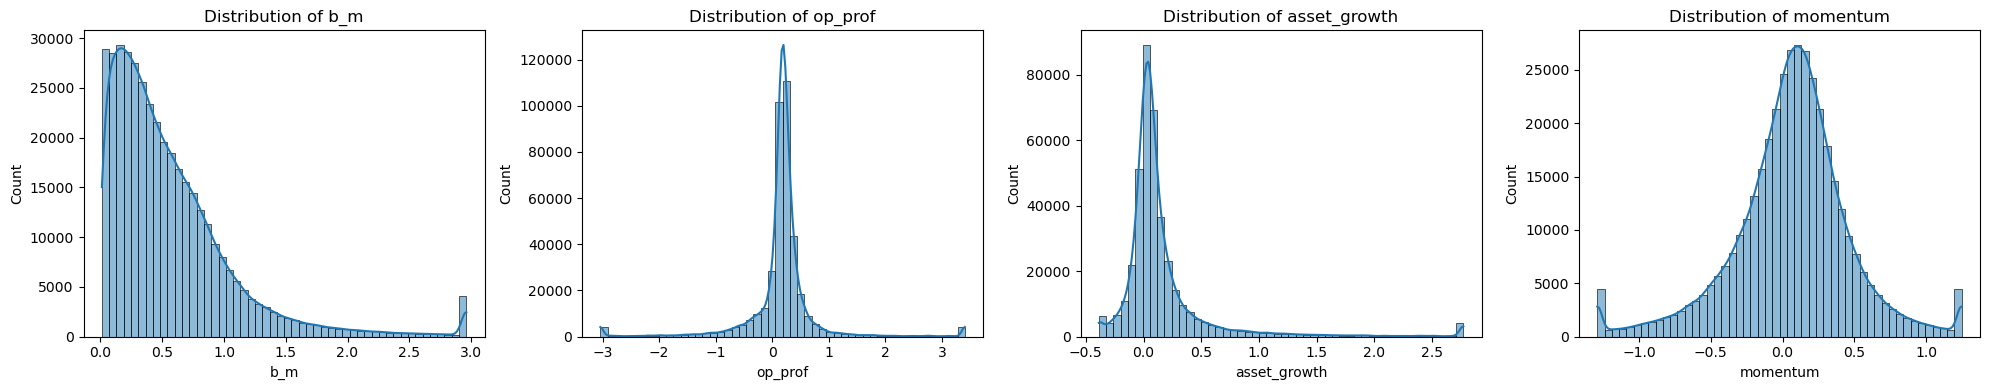

In [109]:
# VISUAL PROOF: Check distributions to ensure no "spikes" remain
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(factors):
    sns.histplot(df_final[col], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()